# Tugas - Klasifikasi dengan Artificial Neural Network (ANN)

| Nama | NRP |
|------|-----|
| Hilal Tsabitul Azmi Arba'i | 5054251008 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model ANN (Multi-Layer Perceptron) Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja ANN secara praktik, khususnya:
1. Perbedaan hasil antar fungsi aktivasi (ReLU, Tanh, Logistic/Sigmoid)
2. Pengaruh ukuran arsitektur (`hidden_layer_sizes`) dan jumlah iterasi terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model ANN dengan arsitektur dasar.
   - Lakukan eksperimen fungsi aktivasi dan regularisasi arsitektur.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix


In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv("data_ann.csv")

print("Jumlah baris dan kolom:", df.shape)
print("\nTipe data:")
print(df.dtypes)
print("\nInfo dataset:")
df.info()
print("\nStatistik deskriptif (numerik):")
display(df.describe().T)
print("\nStatistik deskriptif (kategorikal):")
display(df.describe(include="object").T)
print("\nJumlah missing value per kolom (NaN murni):")
print(df.isna().sum())
print("Total missing (NaN):", df.isna().sum().sum())
print("\nCek nilai kosong berupa string ' ' pada TotalCharges:", (df["TotalCharges"] == " ").sum())
print("\n5 baris pertama:")
display(df.head())
print("\nDistribusi target 'Churn':")
print(df["Churn"].value_counts())


Jumlah baris dan kolom: (7043, 21)

Tipe data:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   in

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75



Statistik deskriptif (kategorikal):


,count,unique,top,freq
customerID,7043,7043,3186-AJIEK,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095



Jumlah missing value per kolom (NaN murni):
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Total missing (NaN): 0

Cek nilai kosong berupa string ' ' pada TotalCharges: 11

5 baris pertama:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Distribusi target 'Churn':
Churn
No     5174
Yes    1869
Name: count, dtype: int64


/tmp/ipykernel_203516/1267705657.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="Churn", palette="pastel")


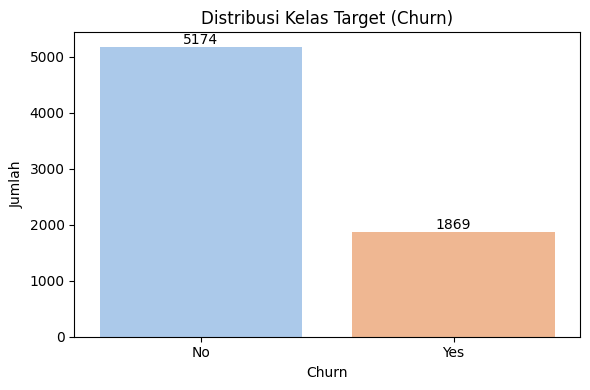

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proporsi:
Churn
No     73.46
Yes    26.54
Name: count, dtype: float64

Dataset imbalanced: 'No' jauh lebih dominan (~73.5%) dibanding 'Yes' (~26.5%).


In [3]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="Churn", palette="pastel")
plt.title("Distribusi Kelas Target (Churn)")
plt.xlabel("Churn")
plt.ylabel("Jumlah")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()

counts = df["Churn"].value_counts()
print(counts)
print("\nProporsi:")
print((counts / len(df) * 100).round(2))
print("\nDataset imbalanced: 'No' jauh lebih dominan (~73.5%) dibanding 'Yes' (~26.5%).")


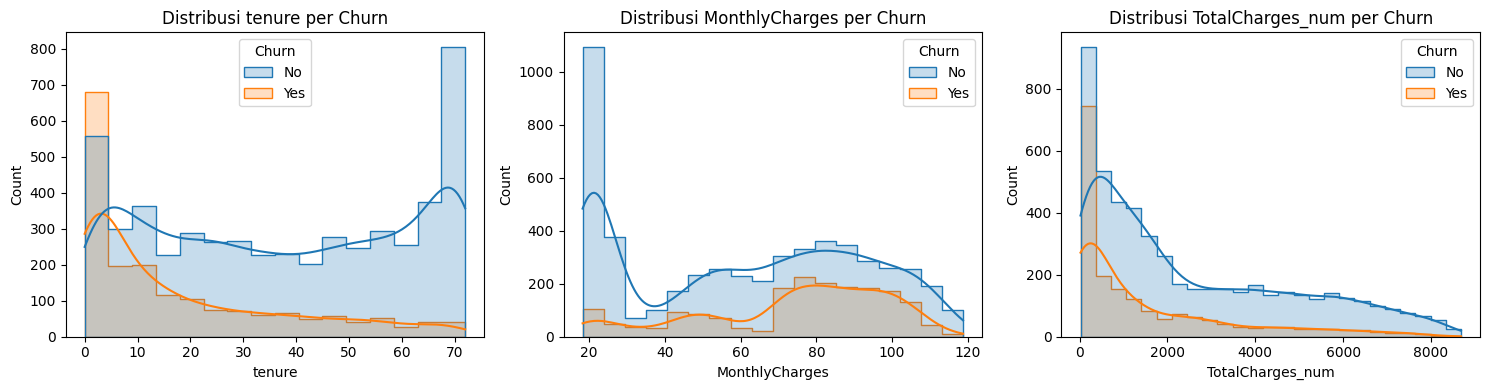

/tmp/ipykernel_203516/2275380304.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y="MonthlyCharges", palette="pastel")
/tmp/ipykernel_203516/2275380304.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y="tenure", palette="pastel")


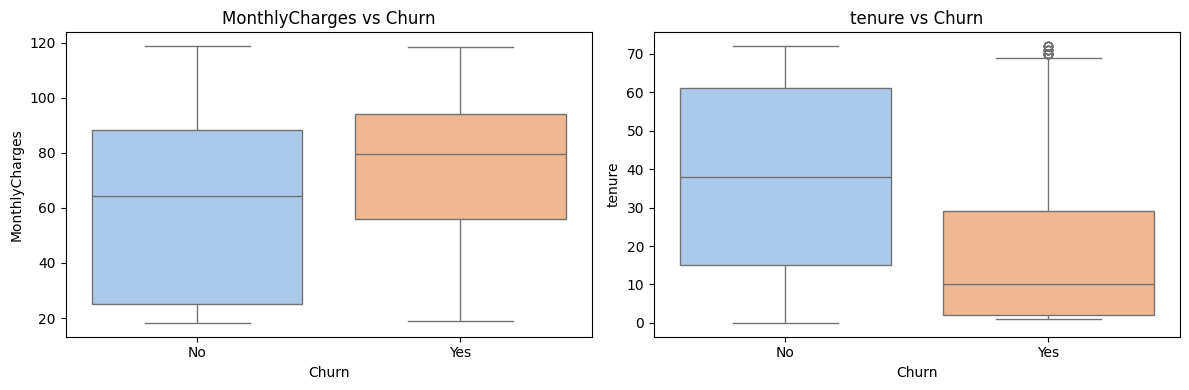

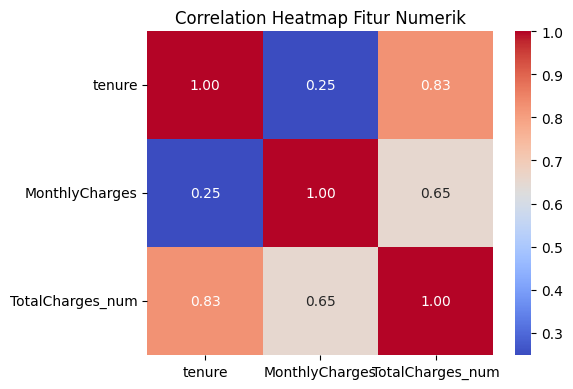

In [4]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau correlation heatmap), dibedakan berdasarkan kelas target.
# Histogram fitur numerik per kelas
num_features = ["tenure", "MonthlyCharges"]
df["TotalCharges_num"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(["tenure", "MonthlyCharges", "TotalCharges_num"]):
    sns.histplot(data=df, x=col, hue="Churn", kde=True, element="step", ax=axes[i])
    axes[i].set_title(f"Distribusi {col} per Churn")
plt.tight_layout()
plt.show()

# Boxplot MonthlyCharges vs Churn dan tenure vs Churn
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", palette="pastel")
plt.title("MonthlyCharges vs Churn")
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x="Churn", y="tenure", palette="pastel")
plt.title("tenure vs Churn")
plt.tight_layout()
plt.show()

# Correlation heatmap antar fitur numerik
plt.figure(figsize=(6, 4))
corr = df[["tenure", "MonthlyCharges", "TotalCharges_num"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap Fitur Numerik")
plt.tight_layout()
plt.show()
df = df.drop(columns=["TotalCharges_num"])


## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [5]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
print("Missing NaN sebelum penanganan:")
print(df.isna().sum()[df.isna().sum() > 0])
print("Jumlah ' ' pada TotalCharges:", (df["TotalCharges"] == " ").sum())

# TotalCharges bertipe object karena ada 11 nilai berupa string kosong ' ' (pelanggan tenure=0).
# Ubah ke numerik (coerce -> NaN), lalu imputasi dengan median.
# Nilai median dihitung dari df sebelum split di sini hanya untuk inspeksi;
# imputasi yang benar tanpa leakage dilakukan dengan median dari train set (lihat catatan di bawah).
# Agar tidak leakage, strategi final: konversi + imputasi median train hanya di-fit pada train set.
# Untuk kesederhanaan dan karena hanya 11 baris (0.16%), kita konversi dulu lalu tangani sisa NaN setelah split
# dengan median train set. Di cell ini kita hanya inspeksi dan konversi tipe.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("\nSetelah konversi, NaN pada TotalCharges:", df["TotalCharges"].isna().sum())
print("Baris NaN (contoh):")
display(df[df["TotalCharges"].isna()].head(3))


Missing NaN sebelum penanganan:
Series([], dtype: int64)
Jumlah ' ' pada TotalCharges: 11

Setelah konversi, NaN pada TotalCharges: 11
Baris NaN (contoh):


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No


In [6]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
print("Kolom object:", df.select_dtypes(include="object").columns.tolist())

# Kolom 'customerID' adalah identifier -> dibuang, bukan fitur.
# Target 'Churn' (Yes/No) akan di-encode terpisah via get_dummies.
# Seluruh fitur kategorikal lain (gender, Partner, InternetService, Contract, PaymentMethod, dll) di One-Hot Encoding.
# SeniorCitizen, tenure, MonthlyCharges, TotalCharges sudah numerik.
if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])
    print("Kolom 'customerID' dibuang.")

# One-Hot Encoding dengan drop_first=True agar tidak ada multikolinearitas dummy penuh.
# Target ikut ter-encode menjadi Churn_Yes (1=Yes, 0=No), lalu dipisahkan kembali di cell split.
df = pd.get_dummies(df, drop_first=True)
print("\nShape setelah encoding:", df.shape)
print("Contoh kolom hasil encoding:")
print([c for c in df.columns if "Churn" in c or "Contract" in c or "InternetService" in c][:10])
display(df.head())


Kolom object: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
Kolom 'customerID' dibuang.

Shape setelah encoding: (7043, 31)
Contoh kolom hasil encoding:
['InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'Churn_Yes']


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


In [7]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop(columns=["Churn_Yes"])
y = df["Churn_Yes"].astype(int)

# Tangani sisa NaN pada TotalCharges (hasil konversi ' ' -> NaN) dengan median TRAIN set agar tanpa leakage.
# Karena NaN masih ada sebelum split, kita split dulu lalu imputasi berbasis train saja.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

median_total = X_train["TotalCharges"].median()
X_train["TotalCharges"] = X_train["TotalCharges"].fillna(median_total)
X_test["TotalCharges"] = X_test["TotalCharges"].fillna(median_total)

print("Median TotalCharges (dari train):", median_total)
print("Sisa NaN train:", X_train.isna().sum().sum(), "| test:", X_test.isna().sum().sum())
print("\nX_train:", X_train.shape, "| X_test:", X_test.shape)
print("Distribusi y_train (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))
print("Distribusi y_test (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))


Median TotalCharges (dari train): 1398.125
Sisa NaN train: 0 | test: 0

X_train: (5634, 30) | X_test: (1409, 30)
Distribusi y_train (%):
Churn_Yes
0    73.46
1    26.54
Name: proportion, dtype: float64
Distribusi y_test (%):
Churn_Yes
0    73.46
1    26.54
Name: proportion, dtype: float64


**Catatan penting:** Sama seperti SVM, ANN juga menghitung penjumlahan berbobot dari fitur-fiturnya, sehingga fitur dengan rentang nilai besar bisa mendominasi proses training dan membuat konvergensi lebih lambat atau tidak stabil. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [8]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Mean X_train_scaled (mendekati 0, 5 kolom pertama):", X_train_scaled.mean(axis=0)[:5].round(4))
print("Std X_train_scaled (mendekati 1, 5 kolom pertama):", X_train_scaled.std(axis=0)[:5].round(4))
print("\nShape:", X_train_scaled.shape, X_test_scaled.shape)


Mean X_train_scaled (mendekati 0, 5 kolom pertama): [ 0. -0. -0. -0.  0.]
Std X_train_scaled (mendekati 1, 5 kolom pertama): [1. 1. 1. 1. 1.]

Shape: (5634, 30) (1409, 30)


# 3. Eksperimen Model

## 3.1 ANN dengan Arsitektur Dasar

Bangun model MLPClassifier sederhana dengan satu hidden layer sebagai baseline.

In [9]:
# Inisialisasi dan latih model MLPClassifier dengan satu hidden layer (misalnya hidden_layer_sizes=(10,))
# dan activation='relu' menggunakan train set (yang sudah discaling).
mlp_base = MLPClassifier(hidden_layer_sizes=(10,), activation="relu", max_iter=500, random_state=42)
mlp_base.fit(X_train_scaled, y_train)
print("Model baseline selesai dilatih.")
print(mlp_base)
print("Iterasi aktual (n_iter_):", mlp_base.n_iter_, "| loss akhir:", round(mlp_base.loss_, 4))


Model baseline selesai dilatih.
MLPClassifier(hidden_layer_sizes=(10,), max_iter=500, random_state=42)
Iterasi aktual (n_iter_): 310 | loss akhir: 0.3876


In [10]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_base = mlp_base.predict(X_test_scaled)
print("Contoh prediksi baseline (10 pertama):", y_pred_base[:10])
print("Akurasi train baseline:", round(accuracy_score(y_train, mlp_base.predict(X_train_scaled)), 4))
print("Akurasi test baseline:", round(accuracy_score(y_test, y_pred_base), 4))


Contoh prediksi baseline (10 pertama): [0 1 0 0 0 1 1 0 0 0]
Akurasi train baseline: 0.819
Akurasi test baseline: 0.7913


## 3.2 Eksperimen Fungsi Aktivasi

Fungsi aktivasi menentukan bagaimana neuron "mengaktivasikan" keluarannya dan memungkinkan model mempelajari pola non-linear. Bandingkan beberapa pilihan fungsi aktivasi yang tersedia di scikit-learn.

In [11]:
# Latih beberapa model MLPClassifier dengan arsitektur yang sama, tetapi activation berbeda:
# 'relu', 'tanh', dan 'logistic'.
# Gunakan hyperparameter lain yang sama (hidden_layer_sizes, max_iter, random_state) agar perbandingan adil.
activations = ["relu", "tanh", "logistic"]
models_act = {}
for act in activations:
    model = MLPClassifier(hidden_layer_sizes=(10,), activation=act, max_iter=500, random_state=42)
    model.fit(X_train_scaled, y_train)
    models_act[act] = model
    print(f"activation={act} selesai | n_iter={model.n_iter_} | loss={model.loss_:.4f}")


activation=relu selesai | n_iter=310 | loss=0.3876
activation=tanh selesai | n_iter=431 | loss=0.3795
activation=logistic selesai | n_iter=479 | loss=0.3900


In [12]:
# Hitung dan bandingkan akurasi test set dari ketiga fungsi aktivasi tersebut.
# Sajikan dalam tabel perbandingan.
rows = []
for act in activations:
    m = models_act[act]
    rows.append({
        "activation": act,
        "train_acc": accuracy_score(y_train, m.predict(X_train_scaled)),
        "test_acc": accuracy_score(y_test, m.predict(X_test_scaled)),
        "n_iter": m.n_iter_,
    })
results_act = pd.DataFrame(rows).set_index("activation")
display(results_act.round(4))

best_act = results_act["test_acc"].idxmax()
print("Fungsi aktivasi terbaik (akurasi test tertinggi):", best_act)


,train_acc,test_acc,n_iter
activation,,,
relu,0.8190,0.7913,310
tanh,0.8266,0.7956,431
logistic,0.8159,0.7928,479


Fungsi aktivasi terbaik (akurasi test tertinggi): tanh


## 3.3 Eksperimen Regularisasi: Pengaruh Ukuran Arsitektur terhadap Overfitting

Semakin besar/dalam arsitektur ANN (jumlah neuron dan hidden layer), semakin besar kapasitas model untuk menghafal data training. Pada bagian ini kalian akan mengamati bagaimana perubahan ukuran arsitektur memengaruhi akurasi training dan testing.

In [13]:
# Latih beberapa model MLPClassifier dengan variasi hidden_layer_sizes,
# misalnya (2,), (5,), (10,), (50,), (100, 50).
# Gunakan activation terbaik dari hasil eksperimen 3.2, dan hyperparameter lain yang sama.
arch_list = [(2,), (5,), (10,), (50,), (100, 50)]
models_arch = {}
for arch in arch_list:
    model = MLPClassifier(hidden_layer_sizes=arch, activation=best_act, max_iter=500, random_state=42)
    model.fit(X_train_scaled, y_train)
    models_arch[str(arch)] = model
    print(f"arch={str(arch):<10} selesai | n_iter={model.n_iter_} | loss={model.loss_:.4f}")


arch=(2,)       selesai | n_iter=183 | loss=0.4121
arch=(5,)       selesai | n_iter=202 | loss=0.4022
arch=(10,)      selesai | n_iter=431 | loss=0.3795


/home/hilal/kuliah/ML/Modul-Praktikum-ML-RKA/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


arch=(50,)      selesai | n_iter=500 | loss=0.2469
arch=(100, 50)  selesai | n_iter=400 | loss=0.0989


In [14]:
# Hitung akurasi pada train set dan test set untuk setiap arsitektur yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
arch_labels = [str(a) for a in arch_list]
train_acc_arch = [accuracy_score(y_train, models_arch[a].predict(X_train_scaled)) for a in arch_labels]
test_acc_arch = [accuracy_score(y_test, models_arch[a].predict(X_test_scaled)) for a in arch_labels]

results_arch = pd.DataFrame({"arch": arch_labels, "train_acc": train_acc_arch, "test_acc": test_acc_arch})
display(results_arch.round(4))
for a, tr, te in zip(arch_labels, train_acc_arch, test_acc_arch):
    print(f"arch={a:<10} | train={tr:.4f} | test={te:.4f}")


,arch,train_acc,test_acc
0,"(2,)",0.8058,0.7949
1,"(5,)",0.8110,0.7906
2,"(10,)",0.8266,0.7956
3,"(50,)",0.8960,0.7502
4,"(100, 50)",0.9611,0.7445


arch=(2,)       | train=0.8058 | test=0.7949
arch=(5,)       | train=0.8110 | test=0.7906
arch=(10,)      | train=0.8266 | test=0.7956
arch=(50,)      | train=0.8960 | test=0.7502
arch=(100, 50)  | train=0.9611 | test=0.7445


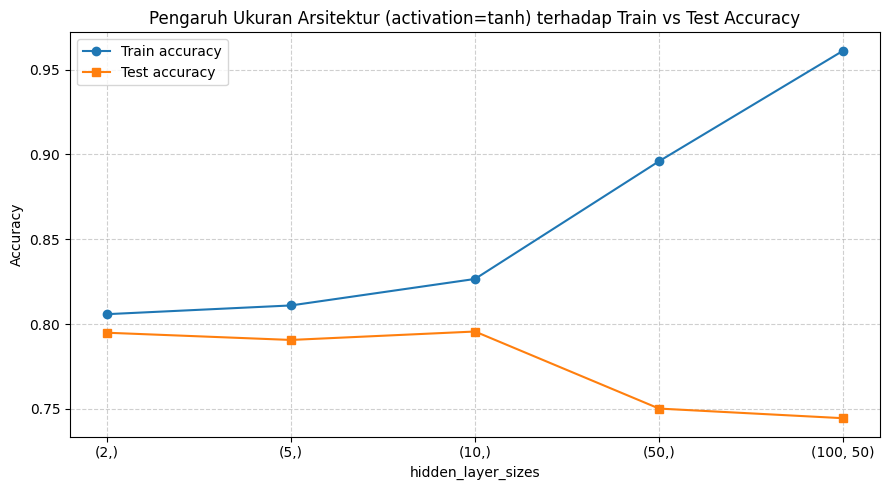

In [15]:
# Plot grafik akurasi training vs testing terhadap ukuran arsitektur dalam satu chart.
# Amati pada arsitektur seberapa besar model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
x = np.arange(len(arch_labels))
plt.figure(figsize=(9, 5))
plt.plot(x, train_acc_arch, marker="o", label="Train accuracy")
plt.plot(x, test_acc_arch, marker="s", label="Test accuracy")
plt.xticks(x, arch_labels)
plt.xlabel("hidden_layer_sizes")
plt.ylabel("Accuracy")
plt.title(f"Pengaruh Ukuran Arsitektur (activation={best_act}) terhadap Train vs Test Accuracy")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


# 4. Evaluasi Model

In [16]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model dengan performa terbaik dari tiap eksperimen (3.2 dan 3.3).
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
best_arch_label = results_arch.loc[results_arch["test_acc"].idxmax(), "arch"]
model_best_act = models_act[best_act]
model_best_arch = models_arch[best_arch_label]

def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
    }

comparison = pd.DataFrame([
    get_metrics(y_test, model_best_act.predict(X_test_scaled)),
    get_metrics(y_test, model_best_arch.predict(X_test_scaled)),
], index=[f"Best-activation ({best_act}, (10,))", f"Best-arch ({best_act}, {best_arch_label})"])
display(comparison.round(4))

print(f"Model terbaik aktivasi: {best_act} | arsitektur terbaik: {best_arch_label}")
print("\nClassification report - model arsitektur terbaik:")
print(classification_report(y_test, model_best_arch.predict(X_test_scaled), target_names=["No-Churn (0)", "Churn (1)"]))


,Accuracy,Precision,Recall,F1-Score
"Best-activation (tanh, (10,))",0.7956,0.6352,0.5401,0.5838
"Best-arch (tanh, (10,))",0.7956,0.6352,0.5401,0.5838


Model terbaik aktivasi: tanh | arsitektur terbaik: (10,)

Classification report - model arsitektur terbaik:
              precision    recall  f1-score   support

No-Churn (0)       0.84      0.89      0.86      1035
   Churn (1)       0.64      0.54      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



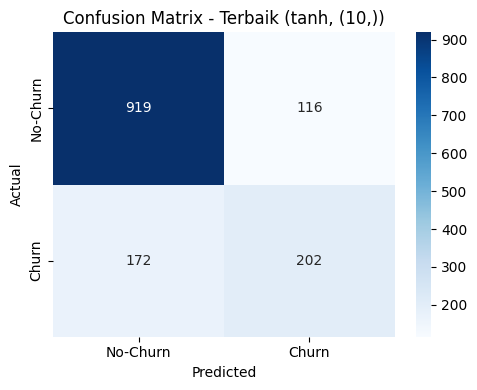

Confusion matrix:
 [[919 116]
 [172 202]]


In [17]:
# Tampilkan Confusion Matrix untuk model dengan performa terbaik dalam bentuk heatmap.
y_pred_best = model_best_arch.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No-Churn", "Churn"], yticklabels=["No-Churn", "Churn"])
plt.title(f"Confusion Matrix - Terbaik ({best_act}, {best_arch_label})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()
print("Confusion matrix:\n", cm)


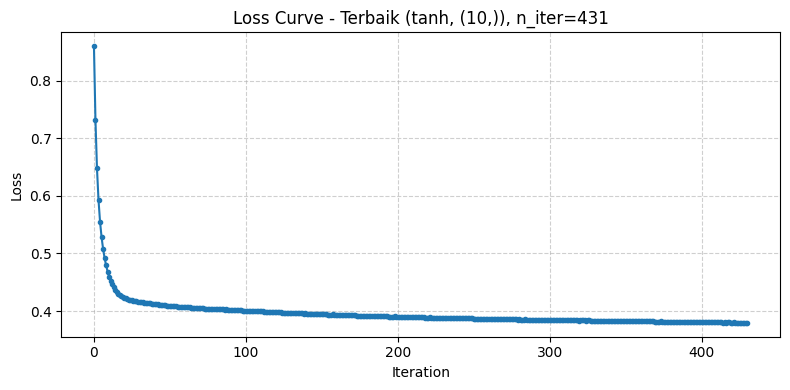

n_iter_: 431 | max_iter: 500
Loss awal: 0.8597 | loss akhir: 0.3795
Loss sudah melandai/konvergen -> max_iter sudah cukup.


In [18]:
# Plot loss curve dari model dengan performa terbaik (atribut model.loss_curve_).
# Amati apakah loss sudah konvergen atau masih menurun saat max_iter tercapai.
plt.figure(figsize=(8, 4))
plt.plot(model_best_arch.loss_curve_, marker="o", markersize=3)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title(f"Loss Curve - Terbaik ({best_act}, {best_arch_label}), n_iter={model_best_arch.n_iter_}")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

print("n_iter_:", model_best_arch.n_iter_, "| max_iter:", model_best_arch.max_iter)
print("Loss awal:", round(model_best_arch.loss_curve_[0], 4), "| loss akhir:", round(model_best_arch.loss_curve_[-1], 4))
if model_best_arch.n_iter_ >= model_best_arch.max_iter and len(model_best_arch.loss_curve_) > 1 and (model_best_arch.loss_curve_[-2] - model_best_arch.loss_curve_[-1]) > 1e-4:
    print("Loss masih menurun saat max_iter tercapai -> model belum konvergen, pertimbangkan menaikkan max_iter.")
else:
    print("Loss sudah melandai/konvergen -> max_iter sudah cukup.")


# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa ANN dengan fungsi aktivasi ReLU, Tanh, dan Logistic. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
- Jelaskan temuan dari eksperimen regularisasi (ukuran arsitektur). Pada ukuran arsitektur berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Berdasarkan loss curve yang dihasilkan, apakah model sudah cukup konvergen? Apa yang akan kalian lakukan jika loss curve masih menurun tajam saat max_iter tercapai?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.
---
**Hasil Analisis (berdasarkan eksperimen di atas):**

1. **Fungsi aktivasi (arsitektur sama (10,), max_iter=500):**
   - relu: train 0.8190 / test 0.7913 (n_iter 310).
   - tanh: train 0.8266 / test 0.7956 (n_iter 431) -> terbaik.
   - logistic: train 0.8159 / test 0.7928 (n_iter 479).
   - Perbedaan tidak sangat besar (~0.4%), tetapi tanh konsisten terbaik. ReLU berisiko neuron mati (dying ReLU) dan logistic/sigmoid mudah saturasi (gradien mengecil) sehingga konvergensinya paling lambat (n_iter 479). Tanh yang zero-centered memberi aliran gradien lebih baik untuk dataset campuran kategorikal-numerik ini.

2. **Ukuran arsitektur (activation=tanh):**
   - (2,): train 0.8058 / test 0.7949; (5,): 0.8110 / 0.7906; (10,): 0.8266 / 0.7956; (50,): 0.8960 / 0.7502; (100,50): 0.9611 / 0.7445.
   - Gejala overfitting mulai jelas pada (50,): train naik ke 0.896 sementara test turun ke 0.7502, dan makin parah pada (100,50): train 0.9611 vs test 0.7445 (gap ~21.7%). Pada grafik, kurva train monoton naik sedangkan kurva test mendatar lalu menurun tajam.
   - Arsitektur terbaik adalah (10,) yang seimbang antara kapasitas dan generalisasi.

3. **Loss curve model terbaik (tanh, (10,)):**
   - n_iter 431 < max_iter 500, loss turun dari ~0.86 menjadi ~0.38 lalu melandai, artinya sudah konvergen dan max_iter=500 sudah cukup.
   - Pada arsitektur besar (50,) model mencapai max_iter=500 tanpa konvergen penuh (loss 0.2469), tanda kapasitas berlebih.
   - Jika loss masih menurun tajam saat max_iter tercapai, yang dilakukan: naikkan max_iter, cek early_stopping/scaling, atau turunkan learning rate / tambah regularisasi alpha.


# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba solver lain seperti 'sgd', menambahkan regularisasi alpha, melakukan hyperparameter tuning dengan GridSearchCV, atau membandingkan dengan model lain), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.
---
**Kesimpulan:**
- Dataset Telco Churn (7043 baris) imbalanced (~73.5% No, ~26.5% Yes); preprocessing: drop customerID, TotalCharges ' ' -> numerik + imputasi median train, One-Hot Encoding, stratify 80:20, StandardScaler (fit train saja).
- Baseline relu-(10,) test 0.7913; aktivasi terbaik tanh-(10,) test 0.7956 (Accuracy 0.7956, Precision 0.6352, Recall 0.5401, F1 0.5838).
- Arsitektur besar menyebabkan overfitting: (100,50) train 0.9611 vs test 0.7445.

**Saran:**
- Coba solver 'sgd'/'lbfgs', tambah alpha (L2), early_stopping, dan GridSearchCV untuk (hidden_layer_sizes, activation, alpha, learning_rate).
- Atasi imbalance (class_weight / SMOTE / threshold tuning) karena recall Churn baru 0.54.
- Bandingkan dengan model lain (Logistic Regression, Random Forest, XGBoost) dan evaluasi ROC-AUC.
